# **Used Car Price Estimator**
### Predicting resale prices from Cardekho India listings using machine learning

**Dataset:** Cardekho India — 15k+ real used car listings (14k+ after cleaning for outliers)

**Tools:** Python , pandas , scikit-learn , XGBoost

## Problem Statement
Used car pricing in India is highly inconsistent — the same model can vary
by ₹2–3 lakh depending on where it is listed. This project builds a
regression pipeline to predict the fair resale price of a used car based
on its specifications, age, usage, and seller details.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

## Load & Inspect Data

We load the Cardekho dataset and explore its structure — shape,
data types, missing values, duplicates, and unique values in
categorical columns.

In [2]:
df = pd.read_csv('cardekho_dataset.csv')

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.shape

(15411, 14)

In [5]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [7]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [8]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.nunique()

Unnamed: 0           15411
car_name               121
brand                   32
model                  120
vehicle_age             24
km_driven             3688
seller_type              3
fuel_type                5
transmission_type        2
mileage                411
engine                 110
max_power              342
seats                    8
selling_price         1086
dtype: int64

In [11]:
cat_cols = df.select_dtypes(include= 'object').columns

for col in cat_cols:
    print(df[col].value_counts())

Hyundai i20           906
Maruti Swift Dzire    890
Maruti Swift          781
Maruti Alto           778
Honda City            757
                     ... 
Mercedes-AMG C          1
Tata Altroz             1
Ferrari GTC4Lusso       1
Hyundai Aura            1
Force Gurkha            1
Name: car_name, Length: 121, dtype: int64
Maruti           4992
Hyundai          2982
Honda            1485
Mahindra         1011
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
Audi              192
Datsun            170
Jaguar             59
Land Rover         51
Jeep               41
Kia                32
Porsche            21
Volvo              20
MG                 19
Mini               17
Nissan             11
Lexus              10
Isuzu               8
Bentley             3
Maserati            2
ISUZU               2
Ferrari             1
Mercedes-AMG        1
Rolls-Royce 

## Data Cleaning

This dataset is already well-structured with no null values or duplicates.
Cleaning steps here are minimal:
- Drop `Unnamed: 0` (carries no information)
- Drop `car_name` (`brand` and `model` already capture this)
- Treat `seats = 0` as invalid data and convert it to missing values.
- Inspect and remove extreme `selling_price` outliers using the IQR rule to reduce the influence of very rare luxury cars.
- After cleaning, the dataset size goes from 15,411 rows to 14,025 rows (about 9% reduction), which keeps most real cars while trimming extremes.

In [12]:
df.drop(columns= ['Unnamed: 0', 'car_name'], inplace= True)

In [13]:
df.loc[df["seats"] == 0, "seats"] = np.nan

In [14]:
# Detect Outliers
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = df[(df['selling_price'] < lower_bound) | (df['selling_price'] > upper_bound)]
print(len(outliers))

1386


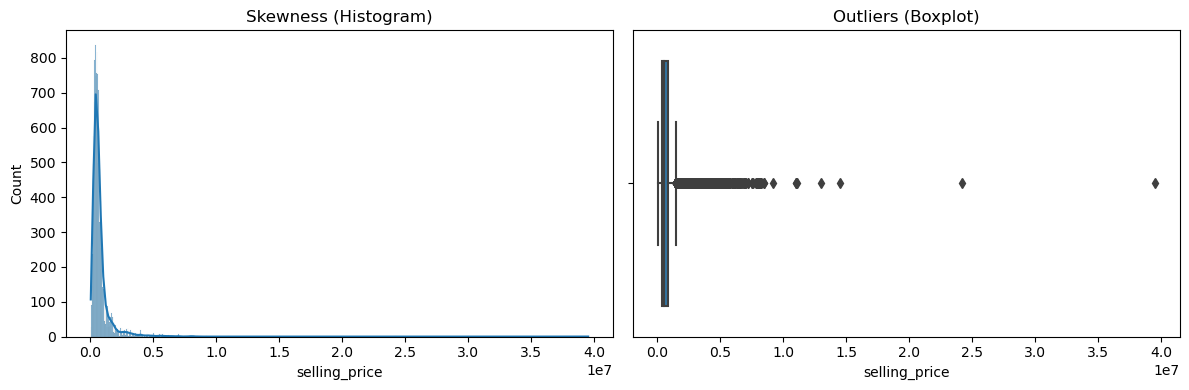

In [15]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['selling_price'], kde=True, ax=ax[0])
ax[0].set_title('Skewness (Histogram)')

sns.boxplot(x= df['selling_price'], ax=ax[1])
ax[1].set_title('Outliers (Boxplot)')

plt.tight_layout()
plt.show()

In [16]:
# Removing outliers

df_clean = df[
    (df['selling_price'] >= lower_bound) &
    (df['selling_price'] <= upper_bound)
].copy()

In [17]:
df_clean.shape

(14025, 12)

## Exploratory Data Analysis
Before modelling, we visualise key relationships in the data to:
- Understand how selling price is distributed
- Identify which features correlate most strongly with price
- Spot patterns in categorical features like fuel type and transmission
- Correlation map - how strongly each numeric feature is related to selling price

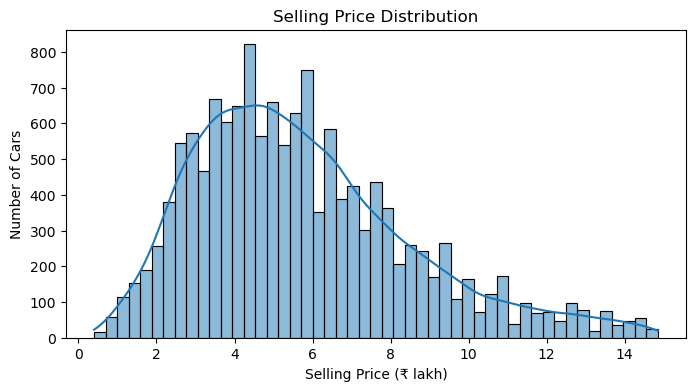

In [18]:
plt.figure(figsize=(8, 4))

sns.histplot(df_clean['selling_price'] / 1e5, kde=True)

plt.title('Selling Price Distribution')
plt.xlabel('Selling Price (₹ lakh)')
plt.ylabel('Number of Cars')
plt.show()

In [19]:
Raw_price_skew = df_clean['selling_price'].skew()

print(f'{Raw_price_skew : .3f}')

 0.839


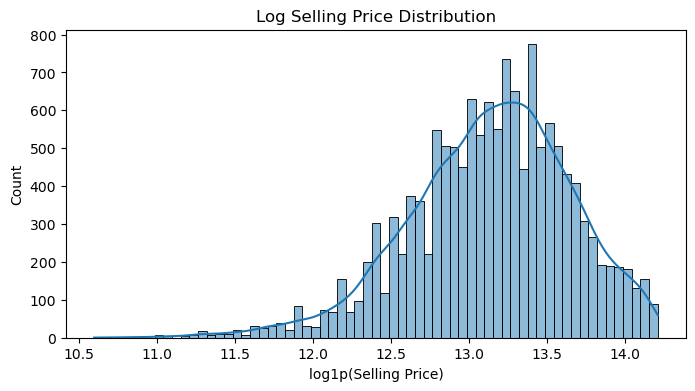

In [20]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df_clean['selling_price']), kde=True)
plt.title('Log Selling Price Distribution')
plt.xlabel('log1p(Selling Price)')
plt.show()

In [21]:
Log_price_skew = np.log1p(df_clean['selling_price']).skew()

print(f'{Log_price_skew : .3f}')

-0.533


### Observation — Selling Price Distribution
- Most cars are priced between ₹3 lakh and ₹8 lakh
- The raw price distribution is right-skewed (skew = 0.839) —
  a small number of premium cars pull the tail towards higher prices
- After applying `log1p` transform, skew reduces to -0.533 —
  closer to normal and better suited for regression models
- The log-transformed price will be used as the target variable for modelling.
- Tree based models (XGBoost, Random Forest) are unaffected by
  skew — the transform mainly benefits Linear and Ridge models

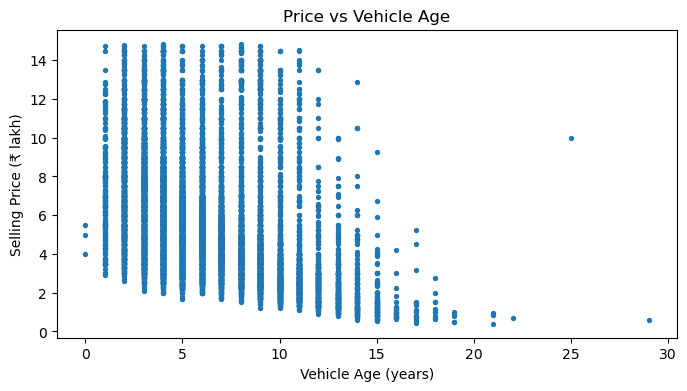

In [22]:
plt.figure(figsize=(8, 4))

plt.scatter(df_clean['vehicle_age'], df_clean['selling_price'] / 1e5, s=8)

plt.title('Price vs Vehicle Age')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Selling Price (₹ lakh)')
plt.show()

### Observation — Price vs Vehicle Age
- Clear depreciation pattern — price drops consistently as vehicle age increases
- Newer cars (0–5 years) have the widest price range
- Cars older than 15 years mostly sell below ₹3 lakh
- Confirms `vehicle_age` is a strong predictor of selling price

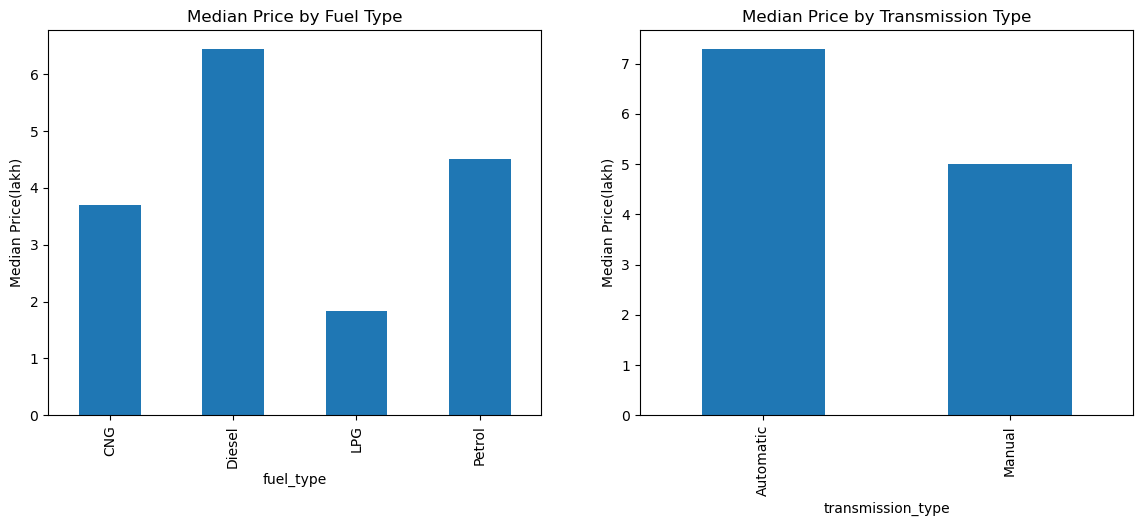

In [23]:
fig, ax = plt.subplots(1, 2, figsize= (14,5))

df_clean.groupby('fuel_type')['selling_price'].median().div(1e5).plot(
    kind= 'bar', ax= ax[0]
)
ax[0].set_title('Median Price by Fuel Type')
ax[0].set_ylabel('Median Price(lakh)')

df_clean.groupby('transmission_type')['selling_price'].median().div(1e5).plot(
    kind= 'bar', ax= ax[1]
)
ax[1].set_title('Median Price by Transmission Type')
ax[1].set_ylabel('Median Price(lakh)')

plt.show()

### Observation — Price by Fuel Type and Transmission
- Diesel cars have the highest median price (above ₹6 lakh) —
  preferred for long distance and fuel efficiency
- LPG cars are the cheapest — very low demand in resale market
- Automatic cars (above ₹7 lakh) are priced significantly higher
  than manual (₹5 lakh) — linked to newer and premium models

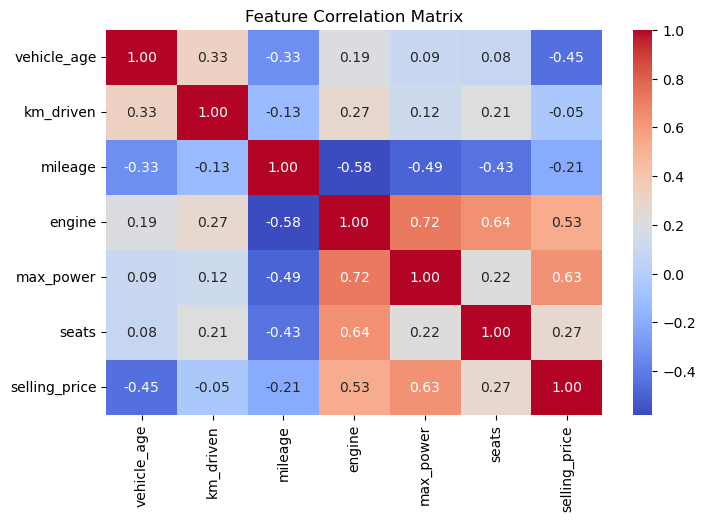

In [24]:
numeric_cols = df_clean.select_dtypes(include= ['int64','float64']).columns

plt.figure(figsize=(8, 5))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True,
            fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

### Observation — Correlation Matrix
- `max_power` has the strongest positive correlation with selling
  price (0.63) — engine power is the biggest driver of resale value
- `vehicle_age` has the strongest negative correlation (-0.45) —
  confirms older cars sell for significantly less
- `km_driven` shows almost no direct correlation (-0.05) with price
  — raw km alone is misleading without considering car age
- `engine` and `max_power` are highly correlated (0.72) but both
  will be retained as they contribute differently to the model

## Feature Engineering

We create two new features before modelling:

- `km_per_year` — normalises km driven by car age, giving a fairer
  picture of how heavily the car was actually used
- For cars with `vehicle_age = 0`, `km_per_year` is undefined, so we set it to `NaN` and let the imputer handle those cases.
- `log_price` — `log1p` transform of the cleaned `selling_price`, which reduces right skew and helps linear models fit better.

After creating these features:
- We drop the original `km_driven` and `selling_price` columns to avoid data leakage and redundancy.
- Later, the regression models will predict `log_price`, and we can exponentiate the predictions back to rupees.

In [25]:
df_clean['km_per_year'] = df_clean['km_driven'] / df_clean['vehicle_age']
df_clean.loc[df_clean['vehicle_age'] == 0, 'km_per_year'] = np.nan

In [26]:
df_clean['log_price'] = np.log1p(df_clean['selling_price'])

In [27]:
df_clean.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,km_per_year,log_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5.0,120000,13333.333333,11.695255
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5.0,550000,4000.000000,13.217675
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5.0,215000,5454.545455,12.278398
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5.0,226000,4111.111111,12.328295
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5.0,570000,5000.000000,13.253393


In [28]:
df_clean.drop(columns= ['km_driven', 'selling_price'], inplace= True)

In [29]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14025 entries, 0 to 15410
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              14025 non-null  object 
 1   model              14025 non-null  object 
 2   vehicle_age        14025 non-null  int64  
 3   seller_type        14025 non-null  object 
 4   fuel_type          14025 non-null  object 
 5   transmission_type  14025 non-null  object 
 6   mileage            14025 non-null  float64
 7   engine             14025 non-null  int64  
 8   max_power          14025 non-null  float64
 9   seats              14023 non-null  float64
 10  km_per_year        14022 non-null  float64
 11  log_price          14025 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 1.4+ MB


In [30]:
np.isinf(df_clean.select_dtypes(include=np.number)).sum()

vehicle_age    0
mileage        0
engine         0
max_power      0
seats          0
km_per_year    0
log_price      0
dtype: int64

In [31]:
df_clean.isnull().sum()

brand                0
model                0
vehicle_age          0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                2
km_per_year          3
log_price            0
dtype: int64

## Model Building

We build a sklearn Pipeline for each model to ensure:
- Identical preprocessing across all models
- No data leakage between train and test sets
- Clean and reproducible code

We compare 4 models from simple to complex:
1. Linear Regression — simple baseline
2. Ridge Regression  — handles multicollinearity
3. Random Forest     — tree based, handles non-linearity
4. XGBoost           — gradient boosting, typically best performer

In [32]:
X = df_clean.drop(columns= ['log_price'])
y = df_clean['log_price']

In [33]:
num_col = X.select_dtypes(include= ['int64','float64']).columns
cat_col = X.select_dtypes(include= ['object']).columns

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state= 42,
                                                    test_size= 0.2)
print(X_train.shape)
print(y_train.shape)

(11220, 11)
(11220,)


In [35]:
num_tran = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

cat_tran = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

In [36]:
preprocessor = ColumnTransformer(transformers= [
    ('num', num_tran, num_col),
    ('cat', cat_tran, cat_col)
])

In [37]:
models = {'Linear Regression': LinearRegression(),
          'Ridge Regression': Ridge(alpha=10, solver='lsqr'),
          'Random Forest': RandomForestRegressor(n_estimators= 200, random_state= 42),
          'XGBoost': XGBRegressor(n_estimators= 100, max_depth= 3, random_state= 42)}

In [38]:
result = []
trained_models = {}
prediction_table = pd.DataFrame({'Actual': np.expm1(y_test).astype(int).values})

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    y_pred = pipe.predict(X_test)

    actual = np.expm1(y_test)
    predicted = np.expm1(y_pred)

    prediction_table[name] = predicted.astype(int)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    result.append({
      'Model': name,
      'MAE': int(mae),
      'RMSE': int(rmse),
      'R2': round(r2, 4)
     })
print(prediction_table.head(10))
results = pd.DataFrame(result).sort_values('RMSE').reset_index(drop= True)
print('\n',results)

   Actual  Linear Regression  Ridge Regression  Random Forest  XGBoost
0  185000             215719            210453         189482   220021
1  219999             214812            225635         219783   239056
2  348999             383375            397178         424418   394124
3  710000             787535            791611         714863   800192
4  199999             220391            229793         184130   177735
5  850000             688667            674555         595902   659469
6  480000             503990            518077         537623   485438
7  299999             218381            227355         225670   204430
8  449999             380860            385173         424719   420950
9  435000             357140            352110         389139   391474

                Model    MAE    RMSE      R2
0            XGBoost  65956   91450  0.8918
1      Random Forest  65708   91922  0.8906
2  Linear Regression  69169   97871  0.8760
3   Ridge Regression  71011  101436  0.86

## Model Comparison
We visualise MAE, RMSE and R² across all 4 models to
identify the best performer clearly.

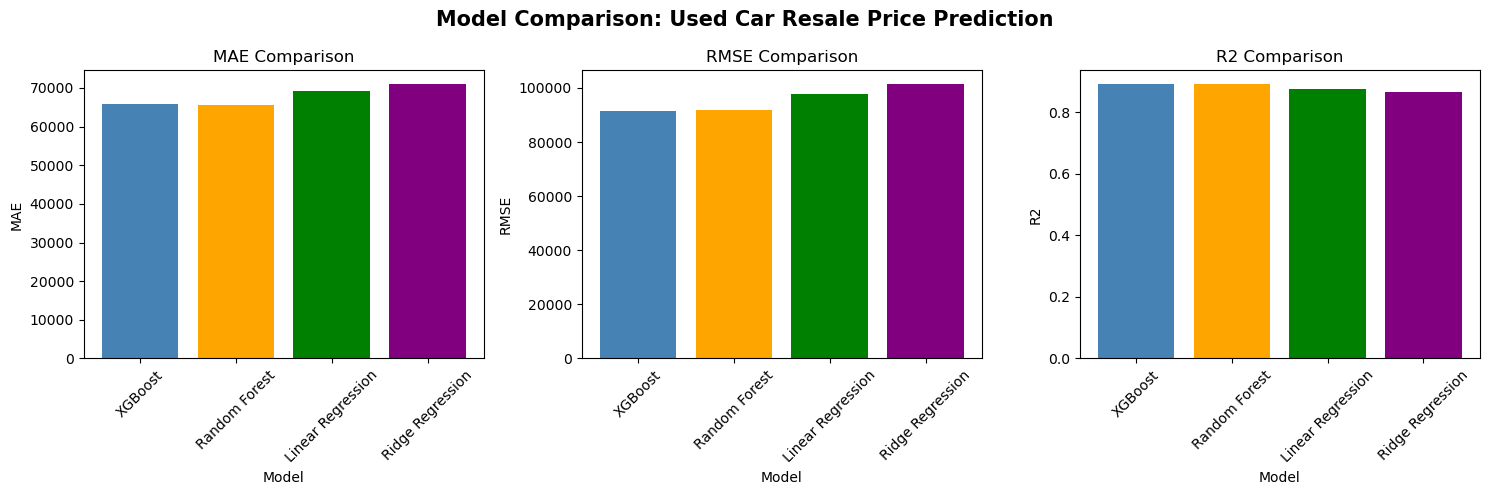

In [39]:
fig, ax = plt.subplots(1, 3, figsize= (15, 5))
plt.suptitle('Model Comparison: Used Car Resale Price Prediction', fontsize= 15, fontweight= 'bold')

metrics = ['MAE', 'RMSE', 'R2']
titles = ['MAE Comparison', 'RMSE Comparison', 'R2 Comparison']

colors = ['steelblue', 'orange', 'green', 'purple']

for i, metric in enumerate(metrics):
    ax[i].bar(results['Model'],
            results[metric],
            color= colors)
    ax[i].set_title(titles[i])
    ax[i].set_xlabel('Model')
    ax[i].set_ylabel(metric)
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Observation — Model Comparison
- XGBoost is the best model across all three metrics —
  lowest MAE (₹66,023), lowest RMSE (₹91,491), highest R² (0.89)
- Random Forest is a close second — nearly identical to XGBoost
- Linear and Ridge underperform on RMSE — struggle with
  non-linear relationships in the data
- All 4 models achieve R² above 0.86 — confirming that the
  selected features carry strong price signal
- XGBoost is selected as the final model for deployment

## Actual vs Predicted Prices
Comparing actual and predicted prices for first 10 test
samples across all 4 models.

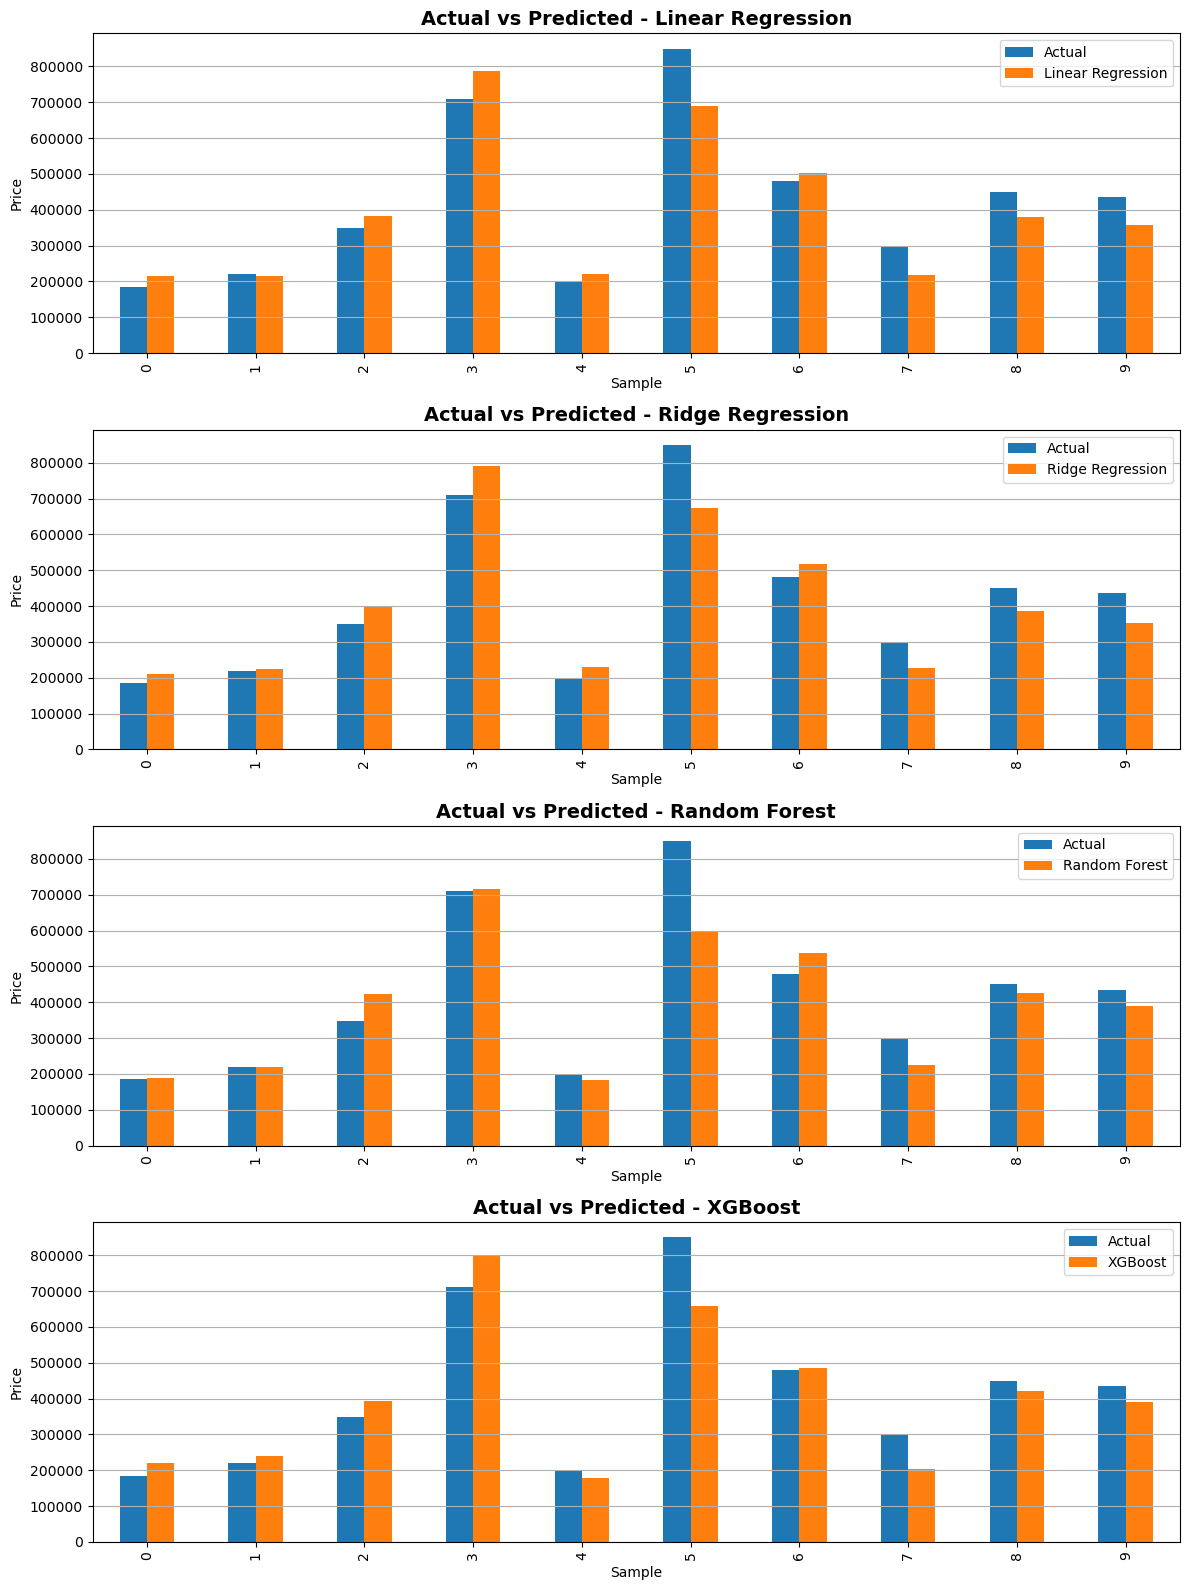

In [40]:
fig, ax = plt.subplots(4, 1, figsize= (12, 16))

for i, model in enumerate(models):
    prediction_table[['Actual', model]].head(10).plot(
      kind= 'bar',
      ax= ax[i]
     )

    ax[i].set_title(f'Actual vs Predicted - {model}',
                  fontsize= 14,
                  fontweight= 'bold')

    ax[i].set_xlabel('Sample')
    ax[i].set_ylabel('Price')
    ax[i].legend()
    ax[i].grid(axis= 'y')

plt.tight_layout()
plt.show()

## Overfitting Check
We compare train R² vs test R² for each model.
A gap above 0.10 indicates overfitting.

In [41]:
for name, pipe in trained_models.items():
    train_r2 = r2_score(y_train, pipe.predict(X_train))
    test_r2 = r2_score(y_test, pipe.predict(X_test))

    gap = train_r2 - test_r2
    flag = 'Possible Overfitting' if gap > 0.10 else 'No Overfitting'

    print(f'{name:<20} trainR2: {train_r2:.2f}   testR2: {test_r2:.2f}   gap: {gap:.2f}   {flag}')

Linear Regression    trainR2: 0.89   testR2: 0.88   gap: 0.01   No Overfitting
Ridge Regression     trainR2: 0.89   testR2: 0.88   gap: 0.01   No Overfitting
Random Forest        trainR2: 0.98   testR2: 0.89   gap: 0.09   No Overfitting
XGBoost              trainR2: 0.91   testR2: 0.90   gap: 0.01   No Overfitting


### Observation — Overfitting Check
- Linear and Ridge show no overfitting (gap = 0.01)
- XGBoost shows no overfitting (gap = 0.01) — best balance
  of performance and generalisation
- Random Forest gap is 0.09 — close to our 0.10 threshold, suggesting it is more complex and slightly overfits compared to XGBoost.
- XGBoost is confirmed as the best model — highest R² on
  test set with minimal overfitting

## Feature Importance

Feature importance shows which features the XGBoost model
relied on most when making predictions.

This helps us understand:
- Which car attributes drive resale price the most
- Whether our engineered feature `km_per_year` added value

In [42]:
best_model = trained_models['XGBoost']

cat_feature_names = (best_model['preprocessor']
                     .named_transformers_['cat']['encoder']
                     .get_feature_names_out(cat_col))

all_feature_names = list(num_col) + list(cat_feature_names)

importance_df = pd.DataFrame({
    'Feature'   : all_feature_names,
    'Importance': best_model['model'].feature_importances_
}).sort_values('Importance', ascending=False).head(10)

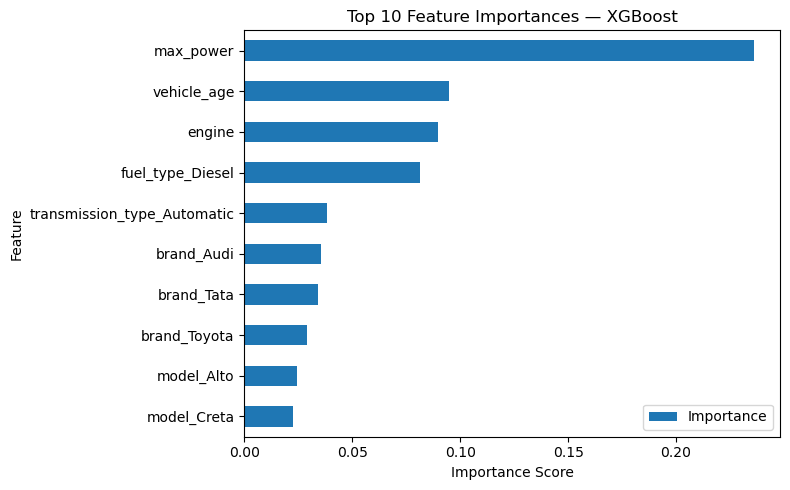

In [43]:
importance_df.sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance',
    figsize=(8, 5)
)
plt.title('Top 10 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [44]:
import joblib
joblib.dump(trained_models['XGBoost'], 'car_price_model.pkl')

['car_price_model.pkl']

## Conclusion

### Results Summary

| Model             | MAE (₹) | RMSE (₹) | R²    |
|-------------------|---------|----------|-------|
| XGBooster           | 66,023  | 91,491   | 0.891 |
| Random Forest     | 65,688  | 91,943   | 0.890 |
| Linear Regression | 69,167  | 97,866   | 0.876 |
| Ridge Regression  | 71,020  | 1,01,439 | 0.866 |

### Key Findings
- XGBoost is the best model with R² of 0.89 — explaining
  89% of price variation in unseen data
- `max_power` and `vehicle_age` are the strongest predictors
  of resale price
- Engineered feature `km_per_year` captured usage intensity
  better than raw `km_driven`
- No significant overfitting detected — Random Forest shows
  a borderline gap of 0.09 but remains within acceptable range

## Sample Prediction

In [45]:
new_car = pd.DataFrame([{
    'brand': 'Hyundai',
    'model': 'i20',
    'vehicle_age': 4,
    'seller_type': 'Dealer',
    'fuel_type': 'Petrol',
    'transmission_type': 'Manual',
    'mileage': 18.5,
    'engine': 1197,
    'max_power': 82.0,
    'seats': 5,
    'km_per_year': 6000
}])

In [46]:
pred_log = trained_models['XGBoost'].predict(new_car)
pred_price = np.expm1(pred_log)[0]
print(f"Predicted Price: ₹{pred_price:,.0f}")

Predicted Price: ₹606,967
